<a href="https://colab.research.google.com/github/utkh-gt/grievance-nlp-system/blob/main/notebooks/Week3_Urgency_Scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Project 1/cleaned_data.csv")

## **Using Vader compound scoring for sentiment score**

In [8]:
!pip install vaderSentiment

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

In [9]:
analyzer = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['Text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

print(df[['Text', 'sentiment_score']].head(10))

                       Text  sentiment_score
0  Street Light Not Working           0.0000
1  Street Light Not Working           0.0000
2              Garbage dump          -0.3818
3  Street Light Not Working           0.0000
4              Garbage dump          -0.3818
5  Street Light Not Working           0.0000
6  Street Light Not Working           0.0000
7  Street Light Not Working           0.0000
8              Garbage dump          -0.3818
9     footpath encroachment           0.0000


In [10]:
def score_to_priority(score):
    if score <= -0.5:
        return "Critical"
    elif score <= -0.1:
        return "High"
    elif score <= 0.2:
        return "Medium"
    else:
        return "Low"

df['priority'] = df['sentiment_score'].apply(score_to_priority)

print(df['priority'].value_counts())

priority
Medium      95088
High        24571
Low          4233
Critical     3082
Name: count, dtype: int64


## **Visualizing sentiment score distribution and priority count**

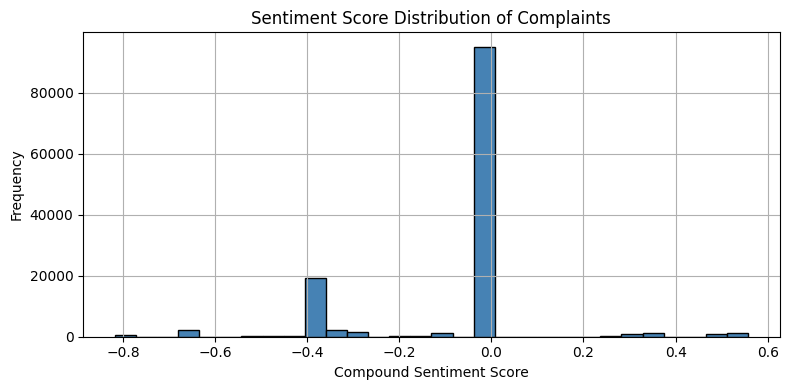

In [11]:
plt.figure(figsize=(8, 4))
df['sentiment_score'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Sentiment Score Distribution of Complaints')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

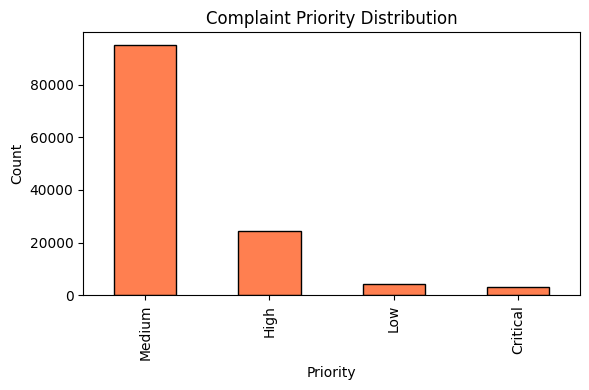

In [12]:
plt.figure(figsize=(6, 4))
df['priority'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Complaint Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('priority_distribution.png')
plt.show()

## **TF-IDF + Logistic Regression model with classification report**

In [43]:
vectorizer_priority = TfidfVectorizer()
X = vectorizer_priority.fit_transform(df['clean_text'])
y = df['priority']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train, y_train)

y_pred = priority_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9997243551880292

Classification Report:
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       286
        High       1.00      1.00      1.00      1107
         Low       1.00      1.00      1.00      8310
      Medium       1.00      1.00      1.00     15692

    accuracy                           1.00     25395
   macro avg       1.00      1.00      1.00     25395
weighted avg       1.00      1.00      1.00     25395



The high accuracy is a known limitation of this dataset. The BBMP dataset
contains only 179 unique complaint types, and priority labels were generated using a rule-based system. As a result, the model learns to replicate these
rules rather than generalizing from true sentiment patterns.

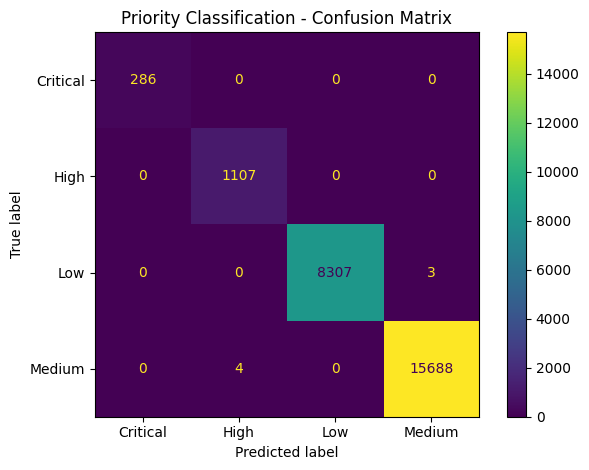

In [44]:
ConfusionMatrixDisplay.from_estimator(priority_model, X_test, y_test)
plt.title("Priority Classification - Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()